## Imports

In [7]:
from src.models.U_net import UNet
from src.train import model_trainer
from src.dataset.dataset import ADE20KDataset, make_train_transform, make_val_transform
from src.utils.params import Params, integrate_global_parameters
from src.preprocessing.verify_model import verify_model_file, verify_model_memorization



In [8]:
parameters : Params = Params('src/config/uNet_params.json')
model = UNet(in_channels=3, base_channels=64, num_classes=parameters.get("num_classes", 151))
global_parameters = Params()
global_parameters = integrate_global_parameters(global_parameters)
dataset = ADE20KDataset(global_parameters.get("train_image_folder"),
                        global_parameters.get("train_annotation_folder"),
                        transform=make_train_transform(
                            mean = global_parameters.get("mean", (0.485, 0.456, 0.406)),
                            std = global_parameters.get("std", (0.229, 0.224, 0.225))
                            )
                        )
verify_model_memorization(model = model, dataset=dataset, sample_size=100, params=parameters, epochs=50)

Training on device: cpu
Using single GPU or CPU


2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/24 12:08:52 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/24 12:08:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/24 12:08:52 INFO mlflow.store.db.utils: Updating database tables
2026/01/24 12:08:52 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/24 12:08:52 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/24 12:08:52 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/24 12:08:52 INFO alembic.runtime

Epoch 1/50, Train Loss: 5.4856
  Validation: {'CombinedLoss': 137.44928741455078, 'DiceLoss': 0.7119981901986259, 'mIoU': 0.0006792959965033722, 'pixel_accuracy': 0.016873632158551897}
  -> Best model saved with val_loss: 137.4493
Most recent model saved to ./models/recent_unet.pt


KeyboardInterrupt: 

=== Batch Shapes ===
Image shape: torch.Size([4, 3, 256, 256])
Mask shape: torch.Size([4, 256, 256])

=== Image Stats ===
Image dtype: torch.float32
Image min: -2.1392, max: 2.3730, mean: 0.3839

=== Mask Stats ===
Mask dtype: torch.int64
Mask unique values count: 133
Mask min: 0, max: 150
Mask value range: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...

=== Model Output Test ===
Model output shape: torch.Size([4, 151, 256, 256])
Model output dtype: torch.float32
Expected shape: (batch=4, num_classes=151, H=256, W=256)

=== Visualization ===


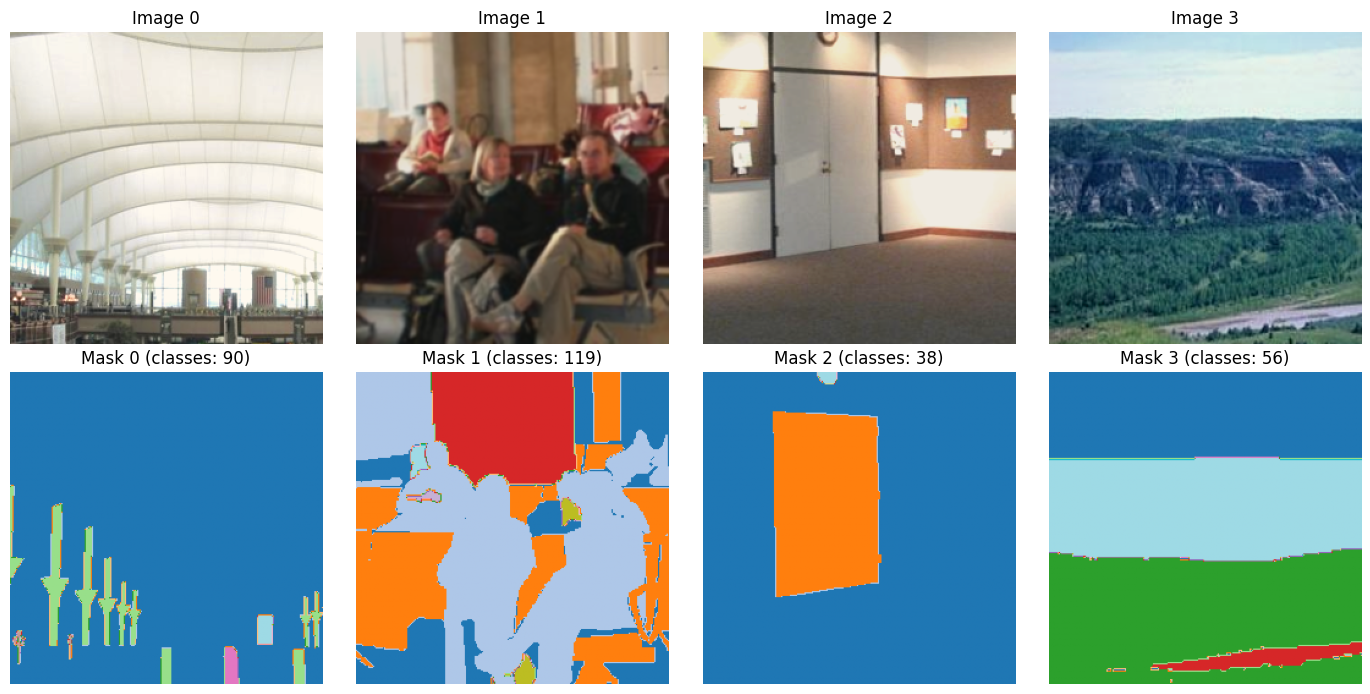

In [ ]:
## Debug: Inspect Batch Data
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Create a small batch from the dataset to inspect
debug_loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)
batch = next(iter(debug_loader))

print("=== Batch Shapes ===")
print(f"Image shape: {batch['image'].shape}")
print(f"Mask shape: {batch['annotation'].shape}")

print("\n=== Image Stats ===")
print(f"Image dtype: {batch['image'].dtype}")
print(f"Image min: {batch['image'].min():.4f}, max: {batch['image'].max():.4f}, mean: {batch['image'].mean():.4f}")

print("\n=== Mask Stats ===")
print(f"Mask dtype: {batch['annotation'].dtype}")
print(f"Mask unique values count: {len(torch.unique(batch['annotation']))}")
print(f"Mask min: {batch['annotation'].min()}, max: {batch['annotation'].max()}")
print(f"Mask value range: {sorted(torch.unique(batch['annotation']).tolist())[:10]}...")  # First 10 unique values

print("\n=== Model Output Test ===")
model_output = model(batch['image'])
print(f"Model output shape: {model_output.shape}")
print(f"Model output dtype: {model_output.dtype}")
print(f"Expected shape: (batch=4, num_classes={parameters.get('num_classes', 151)}, H=256, W=256)")

print("\n=== Visualization ===")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    # Image (denormalize for visualization)
    img = batch['image'][i].permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Denormalize
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis('off')
    
    # Mask (as heatmap)
    mask = batch['annotation'][i].cpu().numpy()
    axes[1, i].imshow(mask, cmap='tab20')
    axes[1, i].set_title(f"Mask {i} (classes: {len(np.unique(mask))})")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## Debug: Check Loss & Metrics Computation

from src.utils.losses import choose_loss
from src.utils.metrics import compute_miou, compute_pixel_accuracy

# Get the batch again
batch = next(iter(debug_loader))
model_output = model(batch['image'])
mask = batch['annotation']

print("=== Loss Function Tests ===")

# Test each loss function
loss_config = parameters.get('validation_loss_params', {})
for loss_name in ['CombinedLoss', 'DiceLoss', 'CrossEntropyLoss']:
    try:
        loss_fn = choose_loss(loss_name, loss_config)
        loss_val = loss_fn(model_output, mask)
        print(f"{loss_name}: {loss_val.item():.6f}")
    except Exception as e:
        print(f"{loss_name}: ERROR - {e}")

print("\n=== Metrics Tests ===")
try:
    miou, _ = compute_miou(model_output, mask, num_classes=151)
    print(f"mIoU: {miou:.6f}")
except Exception as e:
    print(f"mIoU: ERROR - {e}")

try:
    pixel_acc = compute_pixel_accuracy(model_output, mask)
    print(f"Pixel Accuracy: {pixel_acc:.6f}")
except Exception as e:
    print(f"Pixel Accuracy: ERROR - {e}")

print("\n=== Model Prediction Inspection ===")
predictions = torch.argmax(model_output, dim=1)  # Get class predictions
print(f"Prediction shape: {predictions.shape}")
print(f"Unique predicted classes: {len(torch.unique(predictions))}")
print(f"Predicted class distribution (first sample):")
print(f"  Most common: {torch.bincount(predictions[0].flatten()).argmax()}")
print(f"  Is model just predicting one class? {len(torch.unique(predictions[0])) == 1}")

=== Loss Function Tests ===
CombinedLoss: 5.700935
DiceLoss: 0.996734
CrossEntropyLoss: 5.202568

=== Metrics Tests ===
mIoU: 0.000824
Pixel Accuracy: 0.008541

=== Model Prediction Inspection ===
Prediction shape: torch.Size([4, 256, 256])
Unique predicted classes: 146
Predicted class distribution (first sample):
  Most common: 124
  Is model just predicting one class? False


In [ ]:
## Debug: Deep Dive into Metrics Calculation

from src.utils.losses import choose_loss
from src.utils.metrics import compute_miou, compute_pixel_accuracy

batch = next(iter(debug_loader))
model_output = model(batch['image'])
mask = batch['annotation']

print("=== Detailed Accuracy Analysis ===")
predictions = torch.argmax(model_output, dim=1)
print(f"Predictions device: {predictions.device}, dtype: {predictions.dtype}")
print(f"Mask device: {mask.device}, dtype: {mask.dtype}")
print(f"Predictions shape: {predictions.shape}, Mask shape: {mask.shape}")

# Manual pixel accuracy calculation
matches = (predictions == mask).sum().float()
total = mask.numel()
manual_acc = (matches / total).item()
print(f"\nManual calculation:")
print(f"  Matches: {matches.item()} / Total: {total}")
print(f"  Manual Pixel Accuracy: {manual_acc:.6f}")

# Function call
func_acc = compute_pixel_accuracy(model_output, mask)
print(f"Function Pixel Accuracy: {func_acc:.6f}")

print("\n=== Detailed mIoU Analysis (per-class) ===")
miou, iou_per_class = compute_miou(model_output, mask, num_classes=151)
print(f"mIoU: {miou:.6f}")

# Check how many classes have non-zero IoU
non_zero_ious = (iou_per_class > 0).sum().item()
zero_ious = (iou_per_class == 0).sum().item()
nan_ious = torch.isnan(iou_per_class).sum().item()
print(f"Classes with IoU > 0: {non_zero_ious}")
print(f"Classes with IoU == 0: {zero_ious}")
print(f"Classes with NaN: {nan_ious}")

# Show top IoU classes
top_ious, top_indices = torch.topk(iou_per_class, k=10)
print(f"\nTop 10 IoU scores:")
for idx, iou_val in zip(top_indices, top_ious):
    print(f"  Class {idx.item()}: {iou_val.item():.6f}")

# Check if there's a label mismatch
print("\n=== Class Distribution Analysis ===")
unique_pred = torch.unique(predictions)
unique_mask = torch.unique(mask)
print(f"Unique predicted classes: {len(unique_pred)}")
print(f"Unique mask classes: {len(unique_mask)}")
print(f"Overlapping classes: {len(set(unique_pred.tolist()) & set(unique_mask.tolist()))}")

=== Detailed Accuracy Analysis ===
Predictions device: cpu, dtype: torch.int64
Mask device: cpu, dtype: torch.int64
Predictions shape: torch.Size([4, 256, 256]), Mask shape: torch.Size([4, 256, 256])

Manual calculation:
  Matches: 1573.0 / Total: 262144
  Manual Pixel Accuracy: 0.006001
Function Pixel Accuracy: 0.006001

=== Detailed mIoU Analysis (per-class) ===
mIoU: 0.000666
Classes with IoU > 0: 27
Classes with IoU == 0: 124
Classes with NaN: 0

Top 10 IoU scores:
  Class 69: 0.044568
  Class 1: 0.009448
  Class 13: 0.008373
  Class 20: 0.005340
  Class 22: 0.004828
  Class 88: 0.004525
  Class 11: 0.003735
  Class 8: 0.002994
  Class 33: 0.002744
  Class 7: 0.002137

=== Class Distribution Analysis ===
Unique predicted classes: 145
Unique mask classes: 142
Overlapping classes: 137


In [ ]:
## Debug: Model State & Output Distribution

print("=== Model Device & State ===")
print(f"Model device: {next(model.parameters()).device}")
print(f"Model training mode: {model.training}")

# Get fresh batch
batch = next(iter(debug_loader))
print(f"\nBatch image device: {batch['image'].device}")

# Forward pass
model_output = model(batch['image'])
print(f"Model output device: {model_output.device}")
print(f"Model output shape: {model_output.shape}")

# Check output distribution
print("\n=== Model Output Statistics ===")
print(f"Output min: {model_output.min():.6f}, max: {model_output.max():.6f}")
print(f"Output mean: {model_output.mean():.6f}, std: {model_output.std():.6f}")

# Check logit distribution per class
logits_per_class = model_output[0].mean(dim=[1, 2])  # Average across spatial dims
print(f"\nMean logit per class (first sample, first 20 classes):")
print(logits_per_class[:20])

# Check if model is biased toward certain classes
predictions = torch.argmax(model_output, dim=1)
pred_class_dist = torch.bincount(predictions.flatten(), minlength=151)
print(f"\n=== Prediction Class Distribution ===")
top_predicted = torch.topk(pred_class_dist, k=10)
print(f"Top 10 most predicted classes:")
for cls_idx, count in zip(top_predicted.indices, top_predicted.values):
    print(f"  Class {cls_idx.item()}: {count.item()} pixels ({count.item()*100/262144:.2f}%)")

# Check ground truth distribution
gt_class_dist = torch.bincount(mask.flatten(), minlength=151)
top_gt = torch.topk(gt_class_dist, k=10)
print(f"\nTop 10 most common GT classes:")
for cls_idx, count in zip(top_gt.indices, top_gt.values):
    print(f"  Class {cls_idx.item()}: {count.item()} pixels ({count.item()*100/262144:.2f}%)")

=== Model Device & State ===
Model device: cpu
Model training mode: True

Batch image device: cpu
Model output device: cpu
Model output shape: torch.Size([4, 151, 256, 256])

=== Model Output Statistics ===
Output min: -7.015647, max: 6.411893
Output mean: 0.016769, std: 0.547674

Mean logit per class (first sample, first 20 classes):
tensor([-0.1936,  0.3165, -0.3304,  0.3024, -0.0812, -0.3197, -0.2311,  0.0640,
         0.3896, -0.5216, -0.1216,  0.2654, -0.2308,  0.1579, -0.2973, -0.0508,
         0.0089,  0.0192,  0.0343,  0.6316], grad_fn=<SliceBackward0>)

=== Prediction Class Distribution ===
Top 10 most predicted classes:
  Class 112: 31876 pixels (12.16%)
  Class 111: 12336 pixels (4.71%)
  Class 110: 12198 pixels (4.65%)
  Class 52: 11879 pixels (4.53%)
  Class 124: 10651 pixels (4.06%)
  Class 76: 10234 pixels (3.90%)
  Class 90: 10210 pixels (3.89%)
  Class 69: 7705 pixels (2.94%)
  Class 122: 7681 pixels (2.93%)
  Class 11: 7608 pixels (2.90%)

Top 10 most common GT classe